# Level 2 — Q-learning Exploration-Schedule Comparison

The first Level 2 experiment showed that Q-learning outperformed SARSA on mean reward, win rate, hits, and survival. This notebook therefore keeps the algorithm fixed as **Q-learning** and compares three exploration schedules:

1. **Constant epsilon**
2. **Linear epsilon decay**
3. **Exponential epsilon decay**

Controlled settings:

- 2000 training episodes
- first 400 episodes use uniformly random actions
- original Level 2 environment reward
- identical environment seeds
- identical Q-learning hyperparameters
- separate evaluation seeds

For a fair schedule comparison, the linear and exponential schedules both decay from `1.0` to `0.05` over the 1600 post-warm-up episodes. The constant schedule uses `epsilon = 0.20`.


## Imports


In [1]:
from pathlib import Path
import sys
from typing import Any, Dict, Optional
from collections import Counter
import pickle
import time

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "paddle_duel_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from paddle_duel_env import (
    PaddleDuelEnv,
    BaseAgent,
    RandomAgent,
    TrackingAgent,
    ACTION_UP,
    ACTION_DOWN,
    ACTION_STAY,
    ACTION_NAMES,
    random_argmax,
    epsilon_greedy_action,
    ensure_q_state,
    decode_tabular_state,
    record_episode,
    animate_episode,
)


## Inspect the Level 2 observation


In [2]:
inspection_env = PaddleDuelEnv(level=2, max_seconds=6)
sample_state, sample_info = inspection_env.reset(seed=0)

print("Raw state:", sample_state)

try:
    print("\nDecoded state:")
    print(decode_tabular_state(sample_state))
except Exception as exc:
    print("decode_tabular_state could not display the state:", exc)

print("\nState length:", len(sample_state))
print("Available info keys:", sorted(sample_info.keys()))


Raw state: (6, 6, 8, 7, 0, 0, 0)

Decoded state:
{'my_paddle_y_bin': 6, 'other_paddle_y_bin': 6, 'ball_x_bin': 8, 'ball_y_bin': 7, 'ball_vx_sign': 0, 'ball_vy_sign': 0, 'speed_bin': 0}

State length: 7
Available info keys: ['ball_speed', 'ball_vx', 'ball_vy', 'ball_x', 'ball_y', 'done_reason', 'draw', 'elapsed_seconds', 'fps', 'last_scorer', 'left_hits', 'left_paddle_y', 'left_points', 'left_score', 'left_total_reward', 'left_won', 'level', 'max_seconds', 'obs_mode', 'opponent_type', 'paddle_height', 'point_draw', 'points_diff', 'reward_decider_used', 'right_hits', 'right_paddle_y', 'right_points', 'right_score', 'right_total_reward', 'right_won', 'score_diff', 'steps', 'winner']


## Schedule-aware Q-learning agent


In [3]:
class ScheduledQLearningAgent(BaseAgent):
    """Tabular Q-learning with a selectable epsilon schedule."""

    def __init__(
        self,
        schedule: str,
        alpha: float = 0.1,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        constant_epsilon: float = 0.20,
        decay_steps: int = 1600,
        name: Optional[str] = None,
        seed: Optional[int] = None,
    ):
        valid_schedules = {"constant", "linear", "exponential"}
        if schedule not in valid_schedules:
            raise ValueError(
                f"schedule must be one of {valid_schedules}, got {schedule!r}"
            )

        if decay_steps <= 0:
            raise ValueError("decay_steps must be positive.")

        self.schedule = schedule
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.epsilon_start = float(epsilon_start)
        self.epsilon_end = float(epsilon_end)
        self.constant_epsilon = float(constant_epsilon)
        self.decay_steps = int(decay_steps)

        self.epsilon = (
            self.constant_epsilon
            if self.schedule == "constant"
            else self.epsilon_start
        )

        self.name = name or f"Q-learning ({schedule})"
        self.n_actions = 3
        self.rng = np.random.default_rng(seed)
        self.Q: Dict[tuple, np.ndarray] = {}

    def reset(self) -> None:
        pass

    def epsilon_for_learning_episode(self, learning_episode: int) -> float:
        """Return epsilon for a post-warm-up learning episode.

        learning_episode starts from zero immediately after the forced-random phase.
        """
        if self.schedule == "constant":
            return self.constant_epsilon

        if self.decay_steps == 1:
            progress = 1.0
        else:
            progress = np.clip(
                learning_episode / (self.decay_steps - 1),
                0.0,
                1.0,
            )

        if self.schedule == "linear":
            epsilon = (
                self.epsilon_start
                + progress * (self.epsilon_end - self.epsilon_start)
            )
            return float(epsilon)

        # Exponential interpolation reaches exactly epsilon_end at progress=1.
        ratio = self.epsilon_end / self.epsilon_start
        epsilon = self.epsilon_start * (ratio ** progress)
        return float(epsilon)

    def set_learning_episode(self, learning_episode: int) -> None:
        self.epsilon = self.epsilon_for_learning_episode(learning_episode)

    def select_action(
        self,
        observation,
        info: Optional[Dict[str, Any]] = None,
        training: bool = False,
    ) -> int:
        state = tuple(observation)

        if training:
            ensure_q_state(self.Q, state, self.n_actions)
            return epsilon_greedy_action(
                self.Q,
                state,
                self.n_actions,
                self.epsilon,
                self.rng,
            )

        # Do not expand the table during evaluation.
        if state not in self.Q:
            return int(self.rng.integers(self.n_actions))

        return random_argmax(self.Q[state], self.rng)

    def update(
        self,
        state,
        action: int,
        reward: float,
        next_state,
        done: bool,
    ) -> None:
        state = tuple(state)
        next_state = tuple(next_state)

        ensure_q_state(self.Q, state, self.n_actions)

        if done:
            target = float(reward)
        else:
            ensure_q_state(self.Q, next_state, self.n_actions)
            target = float(reward) + self.gamma * float(
                np.max(self.Q[next_state])
            )

        td_error = target - float(self.Q[state][action])
        self.Q[state][action] += self.alpha * td_error

    def save(self, path) -> None:
        payload = {
            "schedule": self.schedule,
            "alpha": self.alpha,
            "gamma": self.gamma,
            "epsilon_start": self.epsilon_start,
            "epsilon_end": self.epsilon_end,
            "constant_epsilon": self.constant_epsilon,
            "decay_steps": self.decay_steps,
            "epsilon": self.epsilon,
            "name": self.name,
            "Q": self.Q,
        }

        with open(path, "wb") as file:
            pickle.dump(payload, file)

    @classmethod
    def load(cls, path, seed: Optional[int] = None):
        with open(path, "rb") as file:
            payload = pickle.load(file)

        agent = cls(
            schedule=payload["schedule"],
            alpha=payload["alpha"],
            gamma=payload["gamma"],
            epsilon_start=payload["epsilon_start"],
            epsilon_end=payload["epsilon_end"],
            constant_epsilon=payload["constant_epsilon"],
            decay_steps=payload["decay_steps"],
            name=payload["name"],
            seed=seed,
        )

        agent.epsilon = payload["epsilon"]
        agent.Q = payload["Q"]
        return agent


## Visualize the three epsilon schedules

The first 400 episodes are forced-random for every agent. The curves below show the epsilon used after that warm-up period.


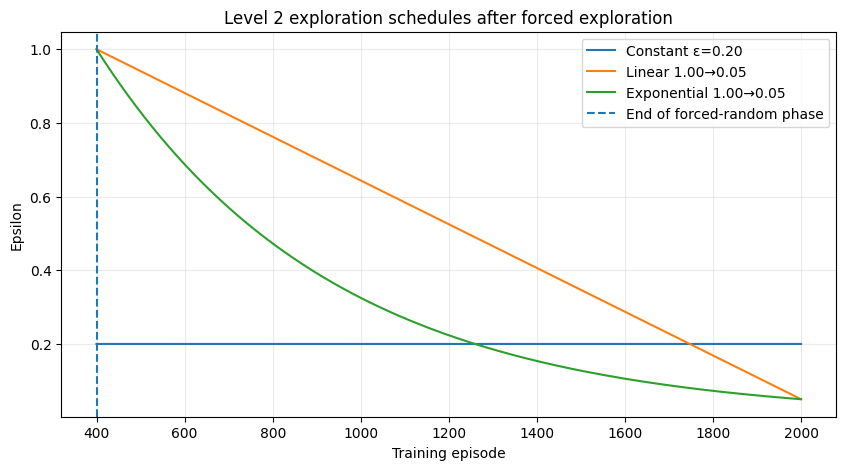

In [4]:
N_TRAIN_EPISODES = 2000
FORCED_EXPLORATION_EPISODES = 400
LEARNING_EPISODES = N_TRAIN_EPISODES - FORCED_EXPLORATION_EPISODES

schedule_preview_agents = {
    "Constant ε=0.20": ScheduledQLearningAgent(
        schedule="constant",
        constant_epsilon=0.20,
        decay_steps=LEARNING_EPISODES,
        seed=1,
    ),
    "Linear 1.00→0.05": ScheduledQLearningAgent(
        schedule="linear",
        epsilon_start=1.0,
        epsilon_end=0.05,
        decay_steps=LEARNING_EPISODES,
        seed=2,
    ),
    "Exponential 1.00→0.05": ScheduledQLearningAgent(
        schedule="exponential",
        epsilon_start=1.0,
        epsilon_end=0.05,
        decay_steps=LEARNING_EPISODES,
        seed=3,
    ),
}

plt.figure(figsize=(10, 5))

x = np.arange(FORCED_EXPLORATION_EPISODES, N_TRAIN_EPISODES)

for name, agent in schedule_preview_agents.items():
    epsilons = [
        agent.epsilon_for_learning_episode(i)
        for i in range(LEARNING_EPISODES)
    ]
    plt.plot(x, epsilons, label=name)

plt.axvline(
    FORCED_EXPLORATION_EPISODES,
    linestyle="--",
    label="End of forced-random phase",
)

plt.xlabel("Training episode")
plt.ylabel("Epsilon")
plt.title("Level 2 exploration schedules after forced exploration")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Training loop


In [5]:
def train_schedule_agent(
    agent: ScheduledQLearningAgent,
    n_episodes: int = 2000,
    seed: int = 0,
    max_seconds: int = 60,
    forced_exploration_episodes: int = 400,
):
    history = {
        "rewards": [],
        "wins": [],
        "hits": [],
        "steps": [],
        "movement_actions": [],
        "stay_actions": [],
        "misses": [],
        "timeouts": [],
        "epsilon": [],
    }

    start_time = time.perf_counter()

    for episode_idx in range(n_episodes):
        env = PaddleDuelEnv(level=2, max_seconds=max_seconds)
        state, info = env.reset(seed=seed + episode_idx)
        agent.reset()

        terminated = False
        truncated = False
        total_reward = 0.0
        steps = 0
        movement_actions = 0
        stay_actions = 0

        in_forced_phase = episode_idx < forced_exploration_episodes

        if in_forced_phase:
            agent.epsilon = 1.0
        else:
            learning_episode = episode_idx - forced_exploration_episodes
            agent.set_learning_episode(learning_episode)

        while not (terminated or truncated):
            if in_forced_phase:
                action = int(agent.rng.integers(agent.n_actions))
            else:
                action = agent.select_action(
                    state,
                    info=info,
                    training=True,
                )

            if action in (ACTION_UP, ACTION_DOWN):
                movement_actions += 1
            else:
                stay_actions += 1

            next_state, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated

            agent.update(
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                done=done,
            )

            state = next_state
            info = next_info
            total_reward += float(reward)
            steps += 1

        history["rewards"].append(total_reward)
        history["wins"].append(float(info.get("winner") == "left"))
        history["hits"].append(int(info.get("left_hits", 0)))
        history["steps"].append(steps)
        history["movement_actions"].append(movement_actions)
        history["stay_actions"].append(stay_actions)
        history["misses"].append(float(info.get("done_reason") == "right_scored"))
        history["timeouts"].append(float(info.get("done_reason") == "timeout"))
        history["epsilon"].append(agent.epsilon)

    history["training_seconds"] = time.perf_counter() - start_time
    return history


## Configure and train the schedule variants


In [6]:
COMMON_CONFIG = {
    "alpha": 0.1,
    "gamma": 0.99,
    "epsilon_start": 1.0,
    "epsilon_end": 0.05,
    "constant_epsilon": 0.20,
    "decay_steps": LEARNING_EPISODES,
}

TRAIN_SEED = 0

schedule_agents = {
    "Constant": ScheduledQLearningAgent(
        schedule="constant",
        name="Q-learning — Constant ε",
        seed=10,
        **COMMON_CONFIG,
    ),
    "Linear": ScheduledQLearningAgent(
        schedule="linear",
        name="Q-learning — Linear decay",
        seed=20,
        **COMMON_CONFIG,
    ),
    "Exponential": ScheduledQLearningAgent(
        schedule="exponential",
        name="Q-learning — Exponential decay",
        seed=30,
        **COMMON_CONFIG,
    ),
}

schedule_histories = {}

for name, agent in schedule_agents.items():
    print(f"Training {name} schedule...")

    schedule_histories[name] = train_schedule_agent(
        agent,
        n_episodes=N_TRAIN_EPISODES,
        seed=TRAIN_SEED,
        forced_exploration_episodes=FORCED_EXPLORATION_EPISODES,
    )

    print(
        f"  learned states: {len(agent.Q):,} | "
        f"time: {schedule_histories[name]['training_seconds']:.1f} s | "
        f"final epsilon: {agent.epsilon:.4f}"
    )


Training Constant schedule...
  learned states: 72,276 | time: 45.1 s | final epsilon: 0.2000
Training Linear schedule...
  learned states: 77,371 | time: 45.4 s | final epsilon: 0.0500
Training Exponential schedule...
  learned states: 76,615 | time: 47.7 s | final epsilon: 0.0500


## Learning-curve comparison


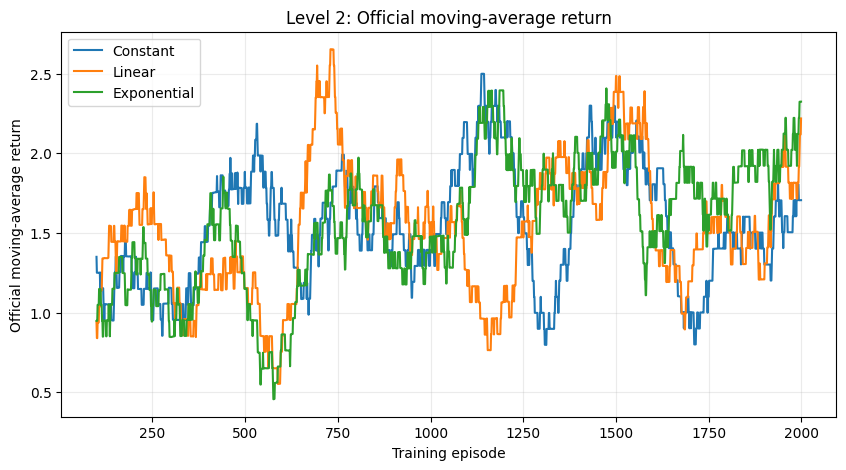

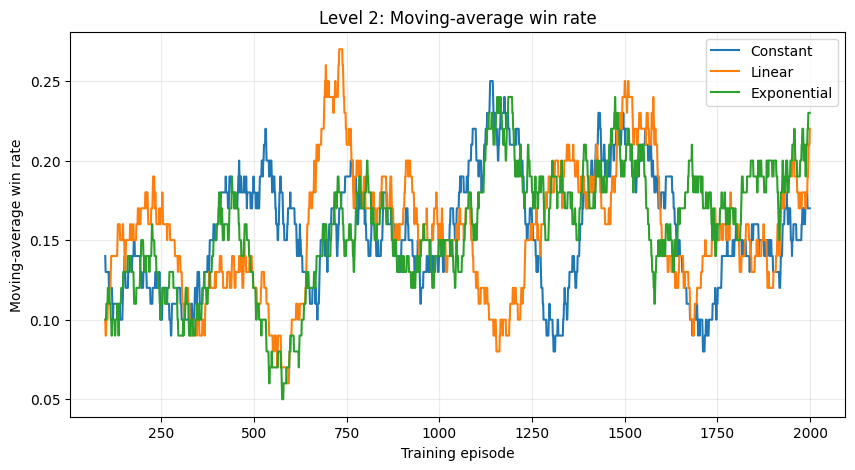

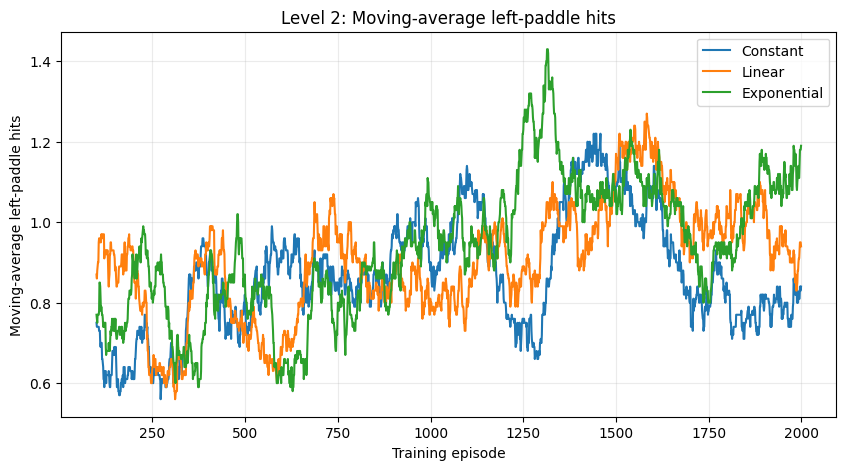

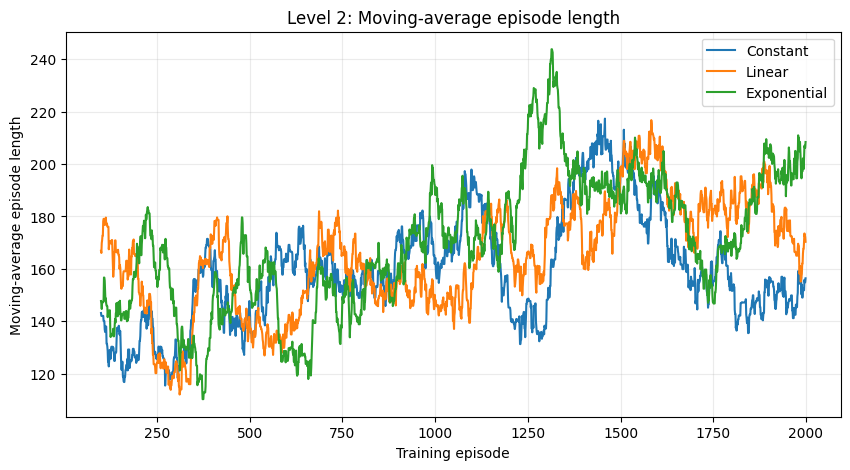

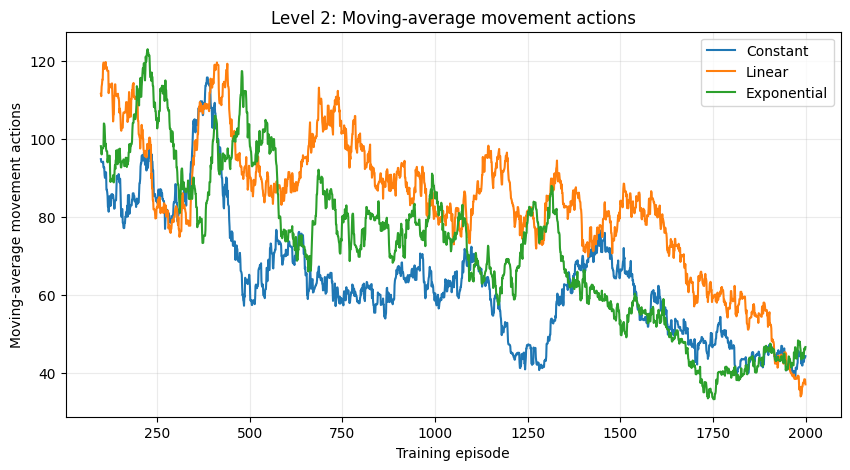

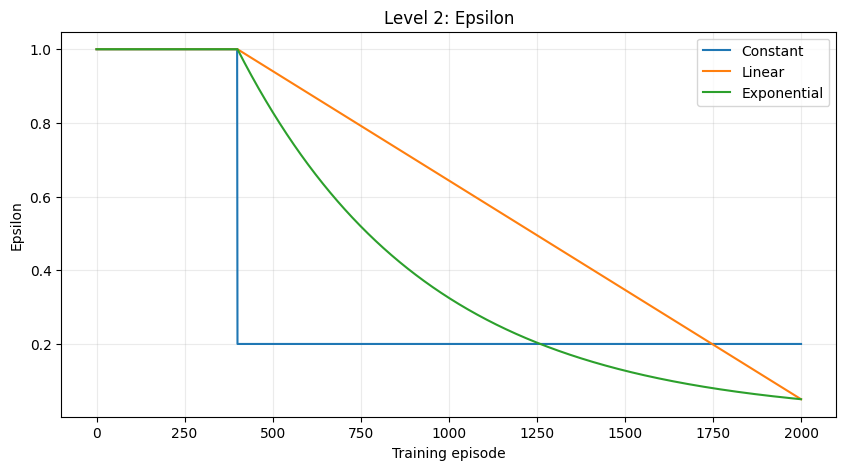

In [7]:
def moving_average(values, window=100):
    values = np.asarray(values, dtype=float)

    if len(values) < window:
        return values

    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


def plot_comparison(schedule_histories, metric, ylabel, window=100):
    plt.figure(figsize=(10, 5))

    for name, history in schedule_histories.items():
        values = np.asarray(history[metric], dtype=float)
        smoothed = moving_average(values, window)

        start = window - 1 if len(values) >= window else 0
        x = np.arange(start, start + len(smoothed))

        plt.plot(x, smoothed, label=name)

    plt.xlabel("Training episode")
    plt.ylabel(ylabel)
    plt.title(f"Level 2: {ylabel}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


plot_comparison(schedule_histories, "rewards", "Official moving-average return")
plot_comparison(schedule_histories, "wins", "Moving-average win rate")
plot_comparison(schedule_histories, "hits", "Moving-average left-paddle hits")
plot_comparison(schedule_histories, "steps", "Moving-average episode length")
plot_comparison(schedule_histories, "movement_actions", "Moving-average movement actions")
plot_comparison(schedule_histories, "epsilon", "Epsilon", window=1)


## Evaluation on unseen seeds

All schedule variants are evaluated greedily on the same 200 unseen seeds. Epsilon is disabled during evaluation, so this measures the quality of the learned policy rather than continued exploration.


In [8]:
def evaluate_level2(
    agent,
    n_episodes: int = 200,
    seed: int = 10_000,
    max_seconds: int = 60,
):
    rewards = []
    wins = []
    hits = []
    steps = []
    movement_counts = []
    stay_counts = []
    misses = []
    timeouts = []

    q_size_before = len(agent.Q) if hasattr(agent, "Q") else None

    for episode_idx in range(n_episodes):
        env = PaddleDuelEnv(level=2, max_seconds=max_seconds)
        observation, info = env.reset(seed=seed + episode_idx)
        agent.reset()

        terminated = False
        truncated = False
        total_reward = 0.0
        movement_count = 0
        stay_count = 0

        while not (terminated or truncated):
            action = agent.select_action(
                observation,
                info=info,
                training=False,
            )

            if action in (ACTION_UP, ACTION_DOWN):
                movement_count += 1
            else:
                stay_count += 1

            observation, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)

        rewards.append(total_reward)
        wins.append(float(info.get("winner") == "left"))
        hits.append(int(info.get("left_hits", 0)))
        steps.append(int(info.get("steps", 0)))
        movement_counts.append(movement_count)
        stay_counts.append(stay_count)
        misses.append(float(info.get("done_reason") == "right_scored"))
        timeouts.append(float(info.get("done_reason") == "timeout"))

    result = {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "win_rate": float(np.mean(wins)),
        "mean_hits": float(np.mean(hits)),
        "std_hits": float(np.std(hits)),
        "max_hits": int(np.max(hits)),
        "mean_steps": float(np.mean(steps)),
        "mean_movement_actions": float(np.mean(movement_counts)),
        "mean_stay_actions": float(np.mean(stay_counts)),
        "miss_rate": float(np.mean(misses)),
        "timeout_rate": float(np.mean(timeouts)),
    }

    if q_size_before is not None:
        result["learned_states"] = int(q_size_before)
        result["q_states_added_during_evaluation"] = int(
            len(agent.Q) - q_size_before
        )

    return result



N_EVAL_EPISODES = 200
EVAL_SEED = 10_000

schedule_evaluation_results = {}

for name, agent in schedule_agents.items():
    result = evaluate_level2(
        agent,
        n_episodes=N_EVAL_EPISODES,
        seed=EVAL_SEED,
    )

    schedule_evaluation_results[name] = result

    print(f"\n{name}")
    for key, value in result.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.4f}")
        else:
            print(f"  {key}: {value}")



Constant
  mean_reward: 1.6729
  std_reward: 3.7317
  win_rate: 0.1650
  mean_hits: 1.0700
  std_hits: 1.5701
  max_hits: 8
  mean_steps: 191.0700
  mean_movement_actions: 41.3150
  mean_stay_actions: 149.7550
  miss_rate: 0.8350
  timeout_rate: 0.0000
  learned_states: 72276
  q_states_added_during_evaluation: 0

Linear
  mean_reward: 2.0746
  std_reward: 4.0581
  win_rate: 0.2050
  mean_hits: 1.2450
  std_hits: 1.5443
  max_hits: 7
  mean_steps: 224.6200
  mean_movement_actions: 50.1400
  mean_stay_actions: 174.4800
  miss_rate: 0.7950
  timeout_rate: 0.0000
  learned_states: 77371
  q_states_added_during_evaluation: 0

Exponential
  mean_reward: 1.8778
  std_reward: 3.9053
  win_rate: 0.1850
  mean_hits: 1.0250
  std_hits: 1.3470
  max_hits: 6
  mean_steps: 186.8850
  mean_movement_actions: 33.7450
  mean_stay_actions: 153.1400
  miss_rate: 0.8150
  timeout_rate: 0.0000
  learned_states: 76615
  q_states_added_during_evaluation: 0


## Compact evaluation table


In [9]:
def compact_evaluation_table(results):
    columns = [
        "agent",
        "mean_reward",
        "std_reward",
        "win_rate",
        "mean_hits",
        "std_hits",
        "max_hits",
        "mean_steps",
        "mean_movement_actions",
        "mean_stay_actions",
        "miss_rate",
        "timeout_rate",
        "learned_states",
    ]

    header = " | ".join(columns)
    print(header)
    print("-" * len(header))

    for name, result in results.items():
        row = {"agent": name, **result}
        values = []

        for column in columns:
            value = row.get(column, "")

            if isinstance(value, float):
                values.append(f"{value:.4f}")
            else:
                values.append(str(value))

        print(" | ".join(values))


compact_evaluation_table(schedule_evaluation_results)


agent | mean_reward | std_reward | win_rate | mean_hits | std_hits | max_hits | mean_steps | mean_movement_actions | mean_stay_actions | miss_rate | timeout_rate | learned_states
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Constant | 1.6729 | 3.7317 | 0.1650 | 1.0700 | 1.5701 | 8 | 191.0700 | 41.3150 | 149.7550 | 0.8350 | 0.0000 | 72276
Linear | 2.0746 | 4.0581 | 0.2050 | 1.2450 | 1.5443 | 7 | 224.6200 | 50.1400 | 174.4800 | 0.7950 | 0.0000 | 77371
Exponential | 1.8778 | 3.9053 | 0.1850 | 1.0250 | 1.3470 | 6 | 186.8850 | 33.7450 | 153.1400 | 0.8150 | 0.0000 | 76615


## Save and reload the schedule agents


In [10]:
SAVE_DIR = PROJECT_ROOT / "saved_agents"
SAVE_DIR.mkdir(exist_ok=True)

saved_schedule_paths = {}

for name, agent in schedule_agents.items():
    filename = f"q_learning_{name.lower()}_level2.pkl"
    save_path = SAVE_DIR / filename

    agent.save(save_path)
    saved_schedule_paths[name] = save_path
    print(f"Saved {name} schedule agent to {save_path}")

reloaded_exponential_agent = ScheduledQLearningAgent.load(
    saved_schedule_paths["Exponential"],
    seed=999,
)

print(
    "\nReloaded exponential agent:",
    len(reloaded_exponential_agent.Q),
    "states",
)


Saved Constant schedule agent to c:\Users\MANAN\Downloads\Project Starter Code_new\saved_agents\q_learning_constant_level2.pkl
Saved Linear schedule agent to c:\Users\MANAN\Downloads\Project Starter Code_new\saved_agents\q_learning_linear_level2.pkl
Saved Exponential schedule agent to c:\Users\MANAN\Downloads\Project Starter Code_new\saved_agents\q_learning_exponential_level2.pkl

Reloaded exponential agent: 76615 states


## Replay diagnostics


In [11]:
REPLAY_SEED = 42
REPLAY_SECONDS = 10

schedule_episodes = {}

for name, agent in schedule_agents.items():
    schedule_episodes[name] = record_episode(
        PaddleDuelEnv(level=2, max_seconds=REPLAY_SECONDS),
        agent,
        seed=REPLAY_SEED,
    )

print("Recorded one greedy replay for each exploration schedule.")


Recorded one greedy replay for each exploration schedule.


In [12]:
def diagnose_episode(name, episode):
    action_counts = Counter(episode.actions)
    positions = [info["left_paddle_y"] for info in episode.infos]
    final_info = episode.infos[-1]

    print(f"\n===== {name} =====")

    print("ACTION COUNTS")
    print(f"  UP   : {action_counts[ACTION_UP]}")
    print(f"  DOWN : {action_counts[ACTION_DOWN]}")
    print(f"  STAY : {action_counts[ACTION_STAY]}")

    print("PADDLE MOVEMENT")
    print(f"  Initial position : {positions[0]:.1f}")
    print(f"  Minimum position : {min(positions):.1f}")
    print(f"  Maximum position : {max(positions):.1f}")
    print(f"  Position range   : {max(positions) - min(positions):.1f} pixels")

    print("EPISODE RESULT")
    print(f"  Hits         : {final_info.get('left_hits', 0)}")
    print(f"  Reward       : {episode.total_reward:.4f}")
    print(f"  Steps        : {final_info.get('steps', len(episode.actions))}")
    print(f"  End reason   : {final_info.get('done_reason')}")
    print(f"  Winner       : {final_info.get('winner')}")

    return positions


replay_positions = {}

for name, episode in schedule_episodes.items():
    replay_positions[name] = diagnose_episode(name, episode)



===== Constant =====
ACTION COUNTS
  UP   : 5
  DOWN : 7
  STAY : 288
PADDLE MOVEMENT
  Initial position : 154.0
  Minimum position : 154.0
  Maximum position : 175.0
  Position range   : 21.0 pixels
EPISODE RESULT
  Hits         : 2
  Reward       : 0.1080
  Steps        : 300
  End reason   : timeout
  Winner       : left

===== Linear =====
ACTION COUNTS
  UP   : 8
  DOWN : 9
  STAY : 283
PADDLE MOVEMENT
  Initial position : 154.0
  Minimum position : 147.0
  Maximum position : 182.0
  Position range   : 35.0 pixels
EPISODE RESULT
  Hits         : 2
  Reward       : 0.1030
  Steps        : 300
  End reason   : timeout
  Winner       : left

===== Exponential =====
ACTION COUNTS
  UP   : 2
  DOWN : 6
  STAY : 130
PADDLE MOVEMENT
  Initial position : 154.0
  Minimum position : 154.0
  Maximum position : 182.0
  Position range   : 28.0 pixels
EPISODE RESULT
  Hits         : 1
  Reward       : 10.0520
  Steps        : 138
  End reason   : left_scored
  Winner       : left


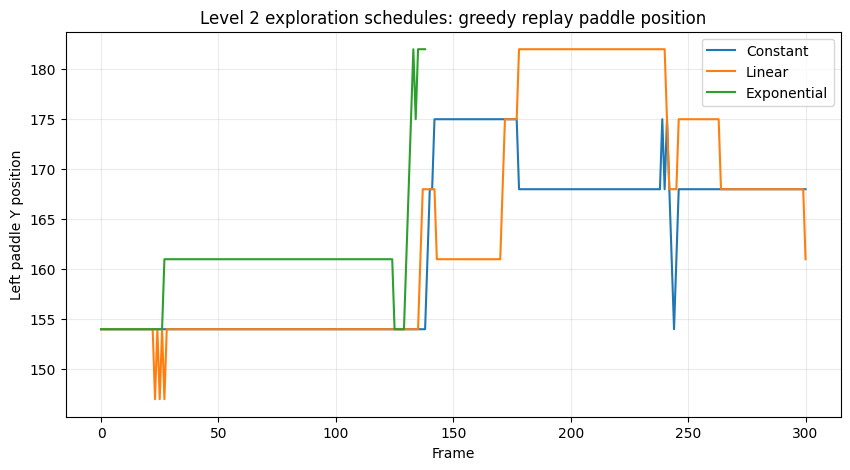

In [13]:
plt.figure(figsize=(10, 5))

for name, positions in replay_positions.items():
    plt.plot(positions, label=name)

plt.xlabel("Frame")
plt.ylabel("Left paddle Y position")
plt.title("Level 2 exploration schedules: greedy replay paddle position")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Animate one schedule


In [14]:
selected_schedule = "Exponential"
animate_episode(schedule_episodes[selected_schedule], interval=30)


## Analysis checklist

Compare the three schedules using:

1. mean reward,
2. win rate,
3. successful hits,
4. episode length,
5. movement and STAY actions,
6. learning speed,
7. reward variability,
8. final learned-state count,
9. replay behavior.

Expected interpretation:

- **Constant epsilon** continues broad exploration throughout training and may learn more slowly or produce a noisier policy.
- **Linear decay** reduces exploration at a uniform rate.
- **Exponential decay** reduces exploration quickly at first and more gradually later.
- The best schedule should produce strong unseen-seed evaluation results, not merely the best training curve.

